# 🪰 SLEAP-NN — top-down training, evaluation & tracking (end-to-end)

Trains a **top-down** pose model on the **flies13** (`wt_gold.13pt`) dataset —
two flies per frame, a 13-node skeleton — and runs it on a fresh video **with
tracking**. A top-down model is two networks: a **centroid** model that locates
each fly (anchored on the `thorax`), and a **centered-instance** model that
predicts the 13-node skeleton inside the crop around each centroid.

This notebook runs **straight through** — download → build configs (saved to
YAML) → train → evaluate on the test split → tracked inference on a clip →
render. A GPU is strongly recommended (this is full-resolution 1024×1024 data)

## Verify all packages installed and function

In [8]:
import sys
import shutil
import urllib.request
from pathlib import Path
from importlib.metadata import version
%matplotlib inline
import matplotlib.pyplot as plt

import torch
from omegaconf import OmegaConf

import sleap_io as sio

from sleap_nn.config.get_config import (
    get_data_config,
    get_model_config,
    get_trainer_config,
)
from sleap_nn.config.training_job_config import TrainingJobConfig
from sleap_nn.train import run_training
from sleap_nn.inference import predict
from sleap_nn.inference.tracking import TrackerConfig
from sleap_nn.evaluation import Evaluator

## Set the correct backend

In [2]:
if torch.cuda.is_available():
    device, device_name = "cuda", torch.cuda.get_device_name(0)
elif (
    getattr(torch.backends, "mps", None) is not None
    and torch.backends.mps.is_available()
):
    device, device_name = "mps", "Apple MPS"
else:
    device, device_name = "cpu", "CPU"

print(f"Using {device} — {device_name}")

Using mps — Apple MPS


## Download and import dataset

**flies13** (`wt_gold.13pt`, `tracking_split2`) — `1024×1024` grayscale frames
with two flies each, as `.pkg.slp` files (labels with embedded images) — plus a
clip for inference.

In [3]:
import ssl
import certifi
import urllib.request


ssl_context = ssl.create_default_context(cafile=certifi.where())

download_opener = urllib.request.build_opener(
    urllib.request.HTTPSHandler(context=ssl_context)
)

urllib.request.install_opener(download_opener)


files = {
    "train.pkg.slp": (
        "https://storage.googleapis.com/sleap-data/datasets/"
        "wt_gold.13pt/tracking_split2/train.pkg.slp"
    ),
    "val.pkg.slp": (
        "https://storage.googleapis.com/sleap-data/datasets/"
        "wt_gold.13pt/tracking_split2/val.pkg.slp"
    ),
    "test.pkg.slp": (
        "https://storage.googleapis.com/sleap-data/datasets/"
        "wt_gold.13pt/tracking_split2/test.pkg.slp"
    ),
    "fly_clip.mp4": (
        "https://storage.googleapis.com/sleap-data/datasets/"
        "wt_gold.13pt/clips/talk_title_slide%4013150-14500.mp4"
    ),
}

for filename, url in files.items():
    if not Path(filename).exists():
        print(f"Downloading {filename}...")
        urllib.request.urlretrieve(url, filename)
    else:
        print(f"Already exists: {filename}")

train_slp = "train.pkg.slp"
val_slp = "val.pkg.slp"
test_slp = "test.pkg.slp"
clip_mp4 = "fly_clip.mp4"

print(f"Files saved in: {Path.cwd()}")

Already exists: train.pkg.slp
Already exists: val.pkg.slp
Already exists: test.pkg.slp
Already exists: fly_clip.mp4
Files saved in: /Users/suraj/Desktop/Projects/Employment Projects/Talmo Lab/SLEAP Python


In [4]:
train_labels = sio.load_slp(train_slp)
val_labels = sio.load_slp(val_slp)
test_labels = sio.load_slp(test_slp)

skeleton = train_labels.skeletons[0]
sample_image = train_labels[0].image

print(
    f"Train / validation / test frames: "
    f"{len(train_labels)} / {len(val_labels)} / {len(test_labels)}"
)

print(
    f"Frame size: {sample_image.shape[1]} × {sample_image.shape[0]}, "
    f"{sample_image.shape[2]} channel(s)"
)

print(
    f"Maximum labeled instances in a training frame: "
    f"{max(len(frame.instances) for frame in train_labels)}"
)

print(f"Skeleton: {len(skeleton.nodes)} nodes")
print("Body parts:", ", ".join(node.name for node in skeleton.nodes))

Train / validation / test frames: 1600 / 200 / 200
Frame size: 1024 × 1024, 1 channel(s)
Maximum labeled instances in a training frame: 2
Skeleton: 13 nodes
Body parts: head, thorax, abdomen, wingL, wingR, forelegL4, forelegR4, midlegL4, midlegR4, hindlegL4, hindlegR4, eyeL, eyeR


## Display a few samples of our data (both unlabeled and labeled)

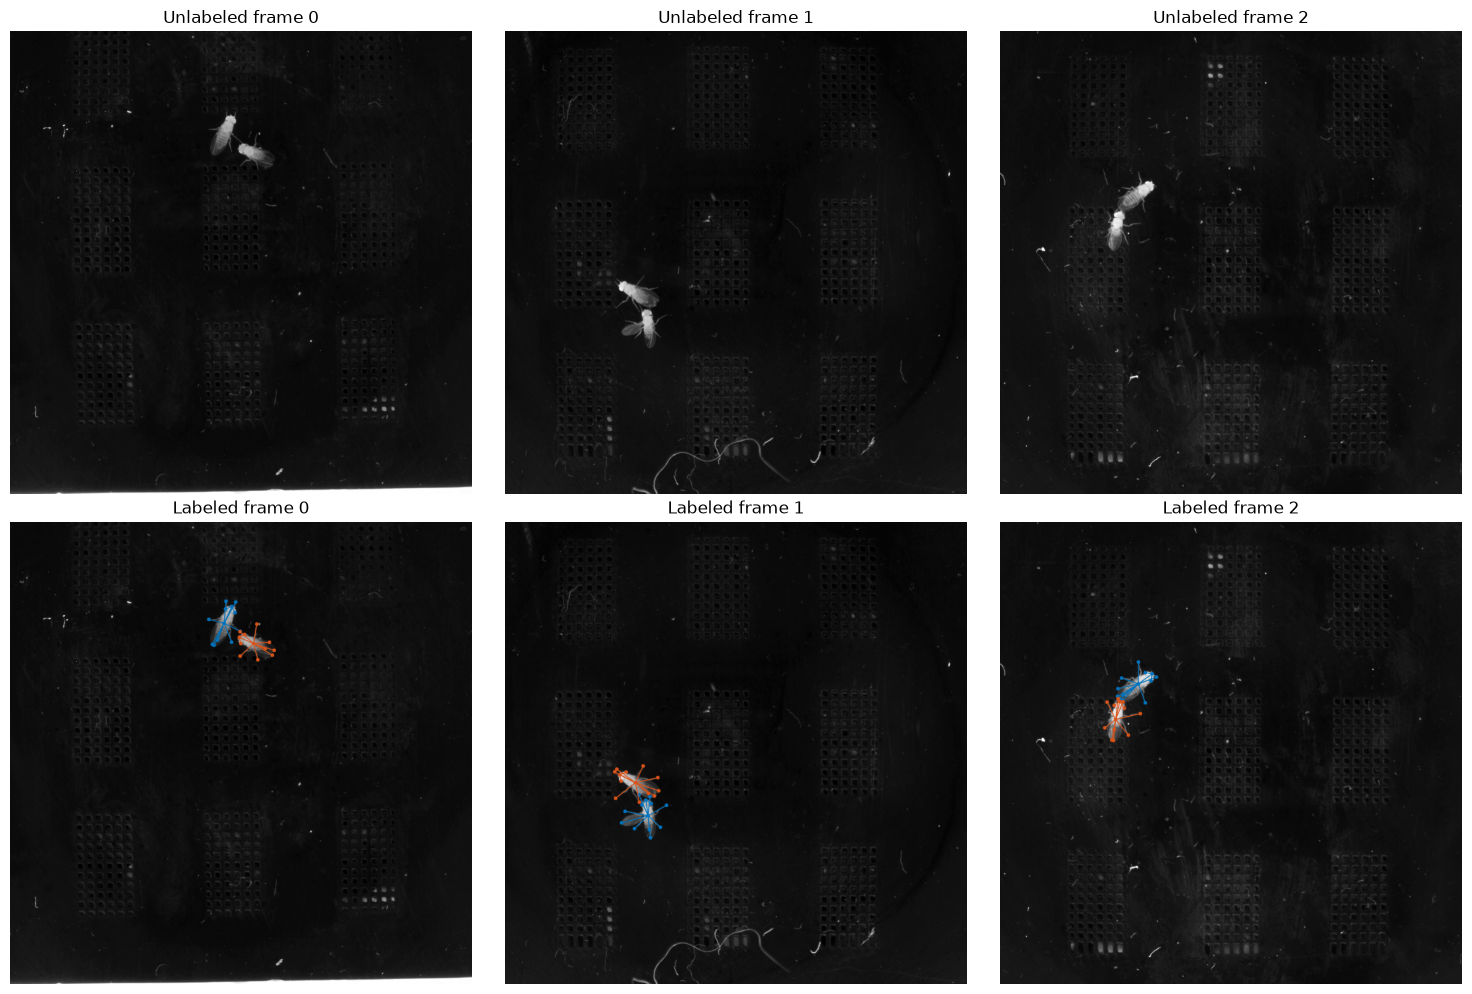

In [7]:
plt.close("all")

number_of_frames = 3

fig, axes = plt.subplots(
    2,
    number_of_frames,
    figsize=(15, 10),
    squeeze=False,
)

for i in range(number_of_frames):
    original_image = train_labels[i].image

    if original_image.ndim == 3 and original_image.shape[-1] == 1:
        original_image = original_image[..., 0]

    axes[0, i].imshow(original_image, cmap="gray")
    axes[0, i].set_title(f"Unlabeled frame {i}")
    axes[0, i].axis("off")

    output_path = f"sample_{i}.png"

    sio.render_image(
        train_labels,
        output_path,
        lf_ind=i,
        color_by="instance",
    )

    axes[1, i].imshow(plt.imread(output_path))
    axes[1, i].set_title(f"Labeled frame {i}")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()
plt.close(fig)

## Build the model configs (→ YAML)

Each model's config is composed with the `sleap_nn.config` builders and saved
to a YAML file. Training then reads those YAMLs — the same path as
`sleap-nn train configs/centroid.yaml`. Shared settings: **±180° rotation**
augmentation, **`thorax`** anchor, **25 epochs**, initial LR **1e-4**, eval
metrics logged each epoch.

In [9]:
# ── Centroid: locate each fly (input scale 0.5, stride 16→2, 16 filters ×2, σ3.5).
centroid_cfg = TrainingJobConfig(
    data_config=get_data_config(
        train_labels_path=["train.pkg.slp"],
        val_labels_path=["val.pkg.slp"],
        data_pipeline_fw="torch_dataset_cache_img_memory",
        scale=0.5,
        use_augmentations_train=True,
        geometry_aug="rotation",
    ),
    model_config=get_model_config(backbone_config="unet", head_configs="centroid"),
    trainer_config=get_trainer_config(
        batch_size=4,
        num_workers=0,
        max_epochs=25,
        learning_rate=1e-4,
        lr_scheduler="reduce_lr_on_plateau",
        save_ckpt=True,
        ckpt_dir="models",
        run_name="centroid",
        visualize_preds_during_training=True,
        trainer_num_devices=1,
    ),
).to_sleap_nn_cfg()
centroid_cfg.model_config.backbone_config.unet.filters = 16
centroid_cfg.model_config.backbone_config.unet.filters_rate = 2.0
centroid_cfg.model_config.backbone_config.unet.max_stride = 16
centroid_cfg.model_config.backbone_config.unet.output_stride = 2
centroid_cfg.model_config.head_configs.centroid.confmaps.sigma = 3.5
centroid_cfg.model_config.head_configs.centroid.confmaps.anchor_part = "thorax"
centroid_cfg.model_config.head_configs.centroid.confmaps.output_stride = 2
centroid_cfg.data_config.augmentation_config.geometric.rotation_min = -180.0
centroid_cfg.data_config.augmentation_config.geometric.rotation_max = 180.0
centroid_cfg.data_config.augmentation_config.geometric.affine_p = 1.0
centroid_cfg.trainer_config.eval.enabled = True

# ── Centered-instance: 13-node skeleton per crop (crop 160, stride 32→4, 24 filters ×1.5, σ2.5).
centered_cfg = TrainingJobConfig(
    data_config=get_data_config(
        train_labels_path=["train.pkg.slp"],
        val_labels_path=["val.pkg.slp"],
        data_pipeline_fw="torch_dataset_cache_img_memory",
        scale=1.0,
        crop_size=160,
        use_augmentations_train=True,
        geometry_aug="rotation",
    ),
    model_config=get_model_config(
        backbone_config="unet", head_configs="centered_instance"
    ),
    trainer_config=get_trainer_config(
        batch_size=8,
        num_workers=0,
        max_epochs=25,
        learning_rate=1e-4,
        lr_scheduler="reduce_lr_on_plateau",
        save_ckpt=True,
        ckpt_dir="models",
        run_name="centered_instance",
        visualize_preds_during_training=True,
        trainer_num_devices=1,
    ),
).to_sleap_nn_cfg()
centered_cfg.model_config.backbone_config.unet.filters = 24
centered_cfg.model_config.backbone_config.unet.filters_rate = 1.5
centered_cfg.model_config.backbone_config.unet.max_stride = 32
centered_cfg.model_config.backbone_config.unet.output_stride = 4
centered_cfg.model_config.head_configs.centered_instance.confmaps.sigma = 2.5
centered_cfg.model_config.head_configs.centered_instance.confmaps.anchor_part = (
    "thorax"
)
centered_cfg.model_config.head_configs.centered_instance.confmaps.output_stride = 4
centered_cfg.data_config.augmentation_config.geometric.rotation_min = -180.0
centered_cfg.data_config.augmentation_config.geometric.rotation_max = 180.0
centered_cfg.data_config.augmentation_config.geometric.affine_p = 1.0
centered_cfg.trainer_config.eval.enabled = True

# To log to Weights & Biases (needs an API key), uncomment and fill in:
# for _cfg in (centroid_cfg, centered_cfg):
#     _cfg.trainer_config.use_wandb = True
#     _cfg.trainer_config.wandb.entity = "<entity>"
#     _cfg.trainer_config.wandb.project = "<project>"
#     _cfg.trainer_config.wandb.api_key = "<key>"

Path("configs").mkdir(exist_ok=True)
OmegaConf.save(centroid_cfg, "configs/centroid.yaml")
OmegaConf.save(centered_cfg, "configs/centered_instance.yaml")

In [10]:
from IPython.display import Markdown, display

for name, cfg in (
    ("centroid", centroid_cfg),
    ("centered_instance", centered_cfg),
):
    yaml_text = OmegaConf.to_yaml(cfg, resolve=True)

    display(
        Markdown(
            f"### {name} configuration\n\n"
            f"```yaml\n{yaml_text}\n```"
        )
    )

### centroid configuration

```yaml
data_config:
  train_labels_path:
  - train.pkg.slp
  val_labels_path:
  - val.pkg.slp
  validation_fraction: 0.1
  use_same_data_for_val: false
  test_file_path: null
  provider: LabelsReader
  user_instances_only: true
  data_pipeline_fw: torch_dataset_cache_img_memory
  cache_img_path: null
  use_existing_imgs: false
  delete_cache_imgs_after_training: true
  parallel_caching: true
  cache_workers: 0
  preprocessing:
    ensure_rgb: false
    ensure_grayscale: false
    max_height: null
    max_width: null
    scale: 0.5
    crop_size: null
    min_crop_size: 100
    crop_padding: null
    tiling:
      enabled: false
      tile_size: null
      overlap: null
      min_overlap_fraction: 0.25
      blend: gaussian
      sigma_scale: 0.125
      tile_batch_size: null
      accumulator_device: auto
      cpu_thresh: 0.4
      sampling: foreground
      tile_fg_fraction: 0.5
      samples_per_frame: null
      center_jitter: 0.5
      min_visible_keypoints: 1
      steps_per_epoch: null
      full_frame_pass: false
  use_augmentations_train: true
  augmentation_config:
    intensity:
      uniform_noise_min: 0.0
      uniform_noise_max: 0.04
      uniform_noise_p: 0.0
      gaussian_noise_mean: 0.0
      gaussian_noise_std: 0.02
      gaussian_noise_p: 0.0
      contrast_min: 0.9
      contrast_max: 1.1
      contrast_p: 0.0
      brightness_min: 0.9
      brightness_max: 1.1
      brightness_p: 0.0
    geometric:
      rotation_min: -180.0
      rotation_max: 180.0
      rotation_p: 1.0
      scale_min: 0.9
      scale_max: 1.1
      scale_p: 1.0
      translate_width: 0.0
      translate_height: 0.0
      translate_p: null
      affine_p: 1.0
      erase_scale_min: 0.0001
      erase_scale_max: 0.01
      erase_ratio_min: 1.0
      erase_ratio_max: 1.0
      erase_p: 0.0
      mixup_lambda_min: 0.01
      mixup_lambda_max: 0.05
      mixup_p: 0.0
      flip_p: 0.0
  use_negative_frames: false
  negative_loss_weight: 1.0
  skeletons: null
model_config:
  init_weights: default
  pretrained_backbone_weights: null
  pretrained_head_weights: null
  backbone_config:
    unet:
      in_channels: 1
      kernel_size: 3
      filters: 16
      filters_rate: 2.0
      max_stride: 16
      stem_stride: null
      middle_block: true
      up_interpolate: true
      stacks: 1
      convs_per_block: 2
      output_stride: 2
    convnext: null
    swint: null
    pretrained: null
  head_configs:
    single_instance: null
    centroid:
      confmaps:
        anchor_part: thorax
        centroid_source: null
        sigma: 3.5
        output_stride: 2
    centered_instance: null
    bottomup: null
    multi_class_bottomup: null
    multi_class_topdown: null
    bottomup_segmentation: null
    centered_instance_segmentation: null
    semantic_segmentation: null
  total_params: null
trainer_config:
  train_data_loader:
    batch_size: 4
    num_workers: 0
    shuffle: true
  val_data_loader:
    batch_size: 4
    num_workers: 0
    shuffle: false
  model_ckpt:
    save_top_k: 1
    save_last: null
    monitor: val/loss
    mode: min
  trainer_devices: 1
  trainer_device_indices: null
  trainer_accelerator: auto
  profiler: null
  trainer_strategy: auto
  enable_progress_bar: true
  min_train_steps_per_epoch: 200
  train_steps_per_epoch: null
  visualize_preds_during_training: true
  keep_viz: false
  viz_img_format: png
  max_epochs: 25
  seed: 42
  use_wandb: false
  save_ckpt: true
  ckpt_dir: models
  run_name: centroid
  resume_ckpt_path: null
  wandb:
    entity: null
    project: null
    name: null
    save_viz_imgs_wandb: false
    api_key: null
    wandb_mode: null
    prv_runid: null
    group: null
    current_run_id: null
    viz_enabled: true
    viz_boxes: false
    viz_masks: false
    viz_box_size: 5.0
    viz_confmap_threshold: 0.1
    log_viz_table: false
    delete_local_logs: null
  optimizer_name: Adam
  optimizer:
    lr: 0.0001
    amsgrad: false
  lr_scheduler:
    step_lr: null
    reduce_lr_on_plateau:
      threshold: 1.0e-06
      threshold_mode: abs
      cooldown: 3
      patience: 5
      factor: 0.5
      min_lr: 1.0e-08
    cosine_annealing_warmup: null
    linear_warmup_linear_decay: null
  early_stopping:
    min_delta: 0.0
    patience: 1
    stop_training_on_plateau: false
  online_hard_keypoint_mining:
    online_mining: false
    hard_to_easy_ratio: 2.0
    min_hard_keypoints: 2
    max_hard_keypoints: null
    loss_scale: 5.0
  zmq:
    controller_port: null
    controller_polling_timeout: 10
    publish_port: null
  eval:
    enabled: true
    frequency: 1
    oks_stddev: 0.025
    oks_scale: null
    match_threshold: 50.0
name: ''
description: ''
sleap_nn_version: 0.3.3
filename: ''

```

### centered_instance configuration

```yaml
data_config:
  train_labels_path:
  - train.pkg.slp
  val_labels_path:
  - val.pkg.slp
  validation_fraction: 0.1
  use_same_data_for_val: false
  test_file_path: null
  provider: LabelsReader
  user_instances_only: true
  data_pipeline_fw: torch_dataset_cache_img_memory
  cache_img_path: null
  use_existing_imgs: false
  delete_cache_imgs_after_training: true
  parallel_caching: true
  cache_workers: 0
  preprocessing:
    ensure_rgb: false
    ensure_grayscale: false
    max_height: null
    max_width: null
    scale: 1.0
    crop_size: 160
    min_crop_size: 100
    crop_padding: null
    tiling:
      enabled: false
      tile_size: null
      overlap: null
      min_overlap_fraction: 0.25
      blend: gaussian
      sigma_scale: 0.125
      tile_batch_size: null
      accumulator_device: auto
      cpu_thresh: 0.4
      sampling: foreground
      tile_fg_fraction: 0.5
      samples_per_frame: null
      center_jitter: 0.5
      min_visible_keypoints: 1
      steps_per_epoch: null
      full_frame_pass: false
  use_augmentations_train: true
  augmentation_config:
    intensity:
      uniform_noise_min: 0.0
      uniform_noise_max: 0.04
      uniform_noise_p: 0.0
      gaussian_noise_mean: 0.0
      gaussian_noise_std: 0.02
      gaussian_noise_p: 0.0
      contrast_min: 0.9
      contrast_max: 1.1
      contrast_p: 0.0
      brightness_min: 0.9
      brightness_max: 1.1
      brightness_p: 0.0
    geometric:
      rotation_min: -180.0
      rotation_max: 180.0
      rotation_p: 1.0
      scale_min: 0.9
      scale_max: 1.1
      scale_p: 1.0
      translate_width: 0.0
      translate_height: 0.0
      translate_p: null
      affine_p: 1.0
      erase_scale_min: 0.0001
      erase_scale_max: 0.01
      erase_ratio_min: 1.0
      erase_ratio_max: 1.0
      erase_p: 0.0
      mixup_lambda_min: 0.01
      mixup_lambda_max: 0.05
      mixup_p: 0.0
      flip_p: 0.0
  use_negative_frames: false
  negative_loss_weight: 1.0
  skeletons: null
model_config:
  init_weights: default
  pretrained_backbone_weights: null
  pretrained_head_weights: null
  backbone_config:
    unet:
      in_channels: 1
      kernel_size: 3
      filters: 24
      filters_rate: 1.5
      max_stride: 32
      stem_stride: null
      middle_block: true
      up_interpolate: true
      stacks: 1
      convs_per_block: 2
      output_stride: 4
    convnext: null
    swint: null
    pretrained: null
  head_configs:
    single_instance: null
    centroid: null
    centered_instance:
      confmaps:
        part_names: null
        anchor_part: thorax
        sigma: 2.5
        output_stride: 4
        loss_weight: 1.0
    bottomup: null
    multi_class_bottomup: null
    multi_class_topdown: null
    bottomup_segmentation: null
    centered_instance_segmentation: null
    semantic_segmentation: null
  total_params: null
trainer_config:
  train_data_loader:
    batch_size: 8
    num_workers: 0
    shuffle: true
  val_data_loader:
    batch_size: 8
    num_workers: 0
    shuffle: false
  model_ckpt:
    save_top_k: 1
    save_last: null
    monitor: val/loss
    mode: min
  trainer_devices: 1
  trainer_device_indices: null
  trainer_accelerator: auto
  profiler: null
  trainer_strategy: auto
  enable_progress_bar: true
  min_train_steps_per_epoch: 200
  train_steps_per_epoch: null
  visualize_preds_during_training: true
  keep_viz: false
  viz_img_format: png
  max_epochs: 25
  seed: 42
  use_wandb: false
  save_ckpt: true
  ckpt_dir: models
  run_name: centered_instance
  resume_ckpt_path: null
  wandb:
    entity: null
    project: null
    name: null
    save_viz_imgs_wandb: false
    api_key: null
    wandb_mode: null
    prv_runid: null
    group: null
    current_run_id: null
    viz_enabled: true
    viz_boxes: false
    viz_masks: false
    viz_box_size: 5.0
    viz_confmap_threshold: 0.1
    log_viz_table: false
    delete_local_logs: null
  optimizer_name: Adam
  optimizer:
    lr: 0.0001
    amsgrad: false
  lr_scheduler:
    step_lr: null
    reduce_lr_on_plateau:
      threshold: 1.0e-06
      threshold_mode: abs
      cooldown: 3
      patience: 5
      factor: 0.5
      min_lr: 1.0e-08
    cosine_annealing_warmup: null
    linear_warmup_linear_decay: null
  early_stopping:
    min_delta: 0.0
    patience: 1
    stop_training_on_plateau: false
  online_hard_keypoint_mining:
    online_mining: false
    hard_to_easy_ratio: 2.0
    min_hard_keypoints: 2
    max_hard_keypoints: null
    loss_scale: 5.0
  zmq:
    controller_port: null
    controller_polling_timeout: 10
    publish_port: null
  eval:
    enabled: true
    frequency: 1
    oks_stddev: 0.025
    oks_scale: null
    match_threshold: 50.0
name: ''
description: ''
sleap_nn_version: 0.3.3
filename: ''

```

## Train

Trains both stages from their YAMLs via `run_training` (the function behind
`sleap-nn train`). This is the slow step — minutes per model on a GPU.

In [11]:
centroid_dir = "models/centroid"
centered_instance_dir = "models/centered_instance"

# Prevent accidentally repeating training over existing results.
for model_dir in (centroid_dir, centered_instance_dir):
    if Path(model_dir).exists():
        raise FileExistsError(
            f"{model_dir} already exists. "
            "Check its contents before starting another training run."
        )

print("Training the centroid model...")
run_training(OmegaConf.load("configs/centroid.yaml"))

print("Training the centered-instance model...")
run_training(OmegaConf.load("configs/centered_instance.yaml"))

print("Both training calls finished.")

Seed set to 42


Training the centroid model...
2026-09-24 09:19:22 | Started training at: 2026-09-24 09:19:22.013142
2026-09-24 09:19:22 | sleap-nn 0.3.3 | Python 3.13.1 | PyTorch 2.14.0 | MPS
2026-09-24 09:19:22 | Creating train-val split...
2026-09-24 09:19:22 | # Train Labeled frames: 1600
2026-09-24 09:19:22 | # Val Labeled frames: 200
2026-09-24 09:19:22 | Setting up config...
2026-09-24 09:19:22 | Setting up for training...
2026-09-24 09:19:22 | Setting up model ckpt dir: `models/centroid`...
2026-09-24 09:19:22 | Setting up visualization train and val datasets...
2026-09-24 09:19:22 | 
%s
centroid_source is NOT set: INFERRING the centroid target from the training labels.
  -> Training on %s for ALL frames.
Set model_config.head_configs.centroid.confmaps.centroid_source to 'user' or
'computed' to make this explicit and silence this warning.
%s
2026-09-24 09:19:22 | Setting up Trainer...
2026-09-24 09:19:22 | Setting up callbacks and loggers...
2026-09-24 09:19:22 | Trainer devices: 1


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


2026-09-24 09:19:22 | 
%s
centroid_source is NOT set: INFERRING the centroid target from the training labels.
  -> Training on %s for ALL frames.
Set model_config.head_configs.centroid.confmaps.centroid_source to 'user' or
'computed' to make this explicit and silence this warning.
%s
2026-09-24 09:19:22 | Caching 1600 images to memory...


Output()

...

2026-09-24 10:22:11 | Epoch 23 evaluation: PCK@5=0.4410, mOKS=0.4036, mAP=0.1092


Validation: |                                            | 0/? [00:00<?, ?it/s]

2026-09-24 10:22:58 | Epoch 24 evaluation: PCK@5=0.4473, mOKS=0.4111, mAP=0.1168


`Trainer.fit` stopped: `max_epochs=25` reached.


2026-09-24 10:22:58 | Finished training loop. [19.3 min]
2026-09-24 10:22:58 | Deleting viz folder at models/centered_instance/viz...
2026-09-24 10:22:58 | Finished training at: 2026-09-24 10:22:58.852012
2026-09-24 10:22:58 | Total training time: 1167.360435962677 secs
2026-09-24 10:22:58 | Training Config: data_config:
  train_labels_path:
  - train.pkg.slp
  val_labels_path:
  - val.pkg.slp
  validation_fraction: 0.1
  use_same_data_for_val: false
  test_file_path: null
  provider: LabelsReader
  user_instances_only: true
  data_pipeline_fw: torch_dataset_cache_img_memory
  cache_img_path: null
  use_existing_imgs: false
  delete_cache_imgs_after_training: true
  parallel_caching: true
  cache_workers: 0
  preprocessing:
    ensure_rgb: false
    ensure_grayscale: false
    max_height: 1024
    max_width: 1024
    scale: 1.0
    crop_size: 160
    min_crop_size: 100
    crop_padding: null
    tiling:
      enabled: false
      tile_size: null
      overlap: null
      min_overlap_fr

In [12]:
zip_path = shutil.make_archive(
    "trained_models",
    "zip",
    root_dir="models",
)

print(f"Saved archive: {Path(zip_path).resolve()}")

Saved archive: /Users/suraj/Desktop/Projects/Employment Projects/Talmo Lab/SLEAP Python/trained_models.zip


## Evaluate on the test split

Run the trained top-down model on the held-out **test** labels and compute pose
metrics (OKS mAP, PCK, keypoint distance) against ground truth.

In [13]:
print("Predicting poses on the test frames...")

test_preds = predict(
    test_labels,
    model_paths=[centroid_dir, centered_instance_dir],
    device=device,
    output_path="test.predictions.slp",
)

print("Comparing predictions with the human annotations...")

metrics = Evaluator(
    ground_truth_instances=test_labels,
    predicted_instances=test_preds,
).evaluate()

metric_summary = {
    "OKS mAP": float(metrics["voc_metrics"]["oks_voc.mAP"]),
    "mPCK": float(metrics["pck_metrics"]["mPCK"]),
    "Distance p50 (px)": float(metrics["distance_metrics"]["p50"]),
    "Distance p90 (px)": float(metrics["distance_metrics"]["p90"]),
}

for name, value in metric_summary.items():
    print(f"{name}: {value:.4f}")


import json

Path("test_metrics_summary.json").write_text(
    json.dumps(metric_summary, indent=2),
    encoding="utf-8",
)

print("\nSaved predictions and metric summary.")

Predicting poses on the test frames...
2026-09-24 10:26:52 | sleap-nn 0.3.3 | Python 3.13.1 | PyTorch 2.14.0 | MPS
2026-09-24 10:26:52 | Loaded inference model | type=centroid+centered_instance | backbone=unet | nodes=13 | device=mps | batch_size=4 | peak_threshold=0.2 | max_instances=None | integral_refinement=integral | paf_workers=0
2026-09-24 10:26:52 | Starting inference | source=Labels | frames=200 | videos=30 | tracking=False
2026-09-24 10:26:57 | Inference complete | frames=200 | instances=400 (2.00/frame) | elapsed=4.9s | throughput=40.9 fps | tracking=False
2026-09-24 10:26:57 | Predictions output path: test.predictions.slp
2026-09-24 10:26:57 | Saved file at: 2026-09-24 10:26:57.959675
Comparing predictions with the human annotations...
OKS mAP: 0.3987
mPCK: 0.6949
Distance p50 (px): 2.5718
Distance p90 (px): 6.8632

Saved predictions and metric summary.


## 5. Tracked inference on a clip

Run the model on a fresh clip **with tracking** so each fly keeps a consistent
identity — capped at **2 instances** using the **local-queues** candidate method
(CLI equivalent: `--tracking --max_instances 2 --candidates_method local_queues`).

In [14]:
print("Predicting and tracking the first 300 frames...")

clip_preds = predict(
    clip_mp4,
    model_paths=[centroid_dir, centered_instance_dir],
    device=device,
    frames=list(range(300)),
    max_instances=2,
    tracker_config=TrackerConfig(
        candidates_method="local_queues",
        max_tracks=2,
        window_size=5,
    ),
    output_path="fly_clip.tracked.slp",
)

track_names = {
    instance.track.name
    for frame in clip_preds
    for instance in frame.instances
    if instance.track is not None
}

number_of_instances = sum(
    len(frame.instances) for frame in clip_preds
)

print(f"Returned labeled frames: {len(clip_preds)}")
print(f"Total predicted instances: {number_of_instances}")
print(f"Track names: {sorted(track_names)}")
print("Saved: fly_clip.tracked.slp")

Predicting and tracking the first 300 frames...
2026-09-24 10:28:22 | sleap-nn 0.3.3 | Python 3.13.1 | PyTorch 2.14.0 | MPS
2026-09-24 10:28:24 | Loaded inference model | type=centroid+centered_instance | backbone=unet | nodes=13 | device=mps | batch_size=4 | peak_threshold=0.2 | max_instances=2 | integral_refinement=integral | paf_workers=0
2026-09-24 10:28:24 | Starting inference | source=fly_clip.mp4 | frames=300 | videos=1 | shape=1024x1024x1 | fps=25.0 | tracking=True
2026-09-24 10:28:31 | Started tracking at: 2026-09-24 10:28:31.613471
2026-09-24 10:28:31 | Finished tracking at: 2026-09-24 10:28:31.834160
2026-09-24 10:28:31 | Total runtime: 0.220689 secs
2026-09-24 10:28:31 | Inference complete | frames=300 | instances=600 (2.00/frame) | elapsed=7.0s | throughput=43.2 fps | tracking=True
2026-09-24 10:28:31 | Predictions output path: fly_clip.tracked.slp
2026-09-24 10:28:31 | Saved file at: 2026-09-24 10:28:31.974423
Returned labeled frames: 300
Total predicted instances: 600
Tr

### Render the tracked predictions (`sio.render_video`)

In [15]:
from IPython.display import Video, display

sio.render_video(
    clip_preds,
    "fly_clip.tracked.viz.mp4",
    fps=30,
    color_by="track",
    show_progress=True,
)

display(
    Video(
        "fly_clip.tracked.viz.mp4",
        embed=True,
        width=800,
    )
)

Rendering: 100%|██████████████████████████| 300/300 [00:05<00:00, 56.09frame/s]


## Export model

In [21]:
import subprocess
import sys
import json
from pathlib import Path

export_dir = Path("exports/flies_topdown")
skeleton = train_labels.skeletons[0]

command = [
    sys.executable,
    "-m",
    "sleap_nn.cli",
    "export",
    "models/centroid",
    "models/centered_instance",
    "--output", str(export_dir),
    "--format", "onnx",
    "--max-instances", "2",
    "--device", "cpu",
    "--verify",
]

subprocess.run(command, check=True)

# Include skeleton connections in the exported model package.
metadata_path = export_dir / "export_metadata.json"
metadata = json.loads(metadata_path.read_text(encoding="utf-8"))

node_indices = {
    name: index
    for index, name in enumerate(metadata["node_names"])
}

metadata["edge_inds"] = [
    [node_indices[source.name], node_indices[destination.name]]
    for source, destination in skeleton.edges
]
metadata["n_edges"] = len(metadata["edge_inds"])

metadata_path.write_text(
    json.dumps(metadata, indent=2),
    encoding="utf-8",
)

print(f"Export saved to: {export_dir.resolve()}")
print(f"Skeleton connections included: {metadata['n_edges']}")

/Users/suraj/Desktop/Projects/Employment Projects/Talmo Lab/SLEAP Python/.venv/lib/python3.13/site-packages/sleap_nn/export/wrappers/topdown.py:76: TracerWarning: Converting a tensor to a Python integer might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  scaled_h = int(height * self.centroid_input_scale)
/Users/suraj/Desktop/Projects/Employment Projects/Talmo Lab/SLEAP Python/.venv/lib/python3.13/site-packages/sleap_nn/export/wrappers/topdown.py:77: TracerWarning: Converting a tensor to a Python integer might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  scaled_w = int(width * self.centroid_input_scale)
/Users/suraj/Desktop/Projects/Employment Projects/Talmo Lab/SLEAP Pyt

Export saved to: /Users/suraj/Desktop/Projects/Employment Projects/Talmo Lab/SLEAP Python/exports/flies_topdown
Skeleton connections included: 12


## Test the exported model

In [23]:
import json
import onnxruntime as ort
from pathlib import Path

export_dir = Path("exports/flies_topdown")

metadata = json.loads(
    (export_dir / "export_metadata.json").read_text(encoding="utf-8")
)

print("EXPORT METADATA")
print(json.dumps(metadata, indent=2))

node_names = metadata["node_names"]
edge_inds = metadata.get("edge_inds", [])

print(f"\nSKELETON: {len(node_names)} body parts, {len(edge_inds)} connections")

for source_index, destination_index in edge_inds:
    print(f"  {node_names[source_index]} → {node_names[destination_index]}")

if not edge_inds:
    print("No connections found. Rendering will show points only.")

session = ort.InferenceSession(
    str(export_dir / "model.onnx"),
    providers=["CPUExecutionProvider"],
)

print("\nMODEL INPUTS")
for item in session.get_inputs():
    print(f"{item.name}: shape={item.shape}, type={item.type}")

print("\nMODEL OUTPUTS")
for item in session.get_outputs():
    print(f"{item.name}: shape={item.shape}, type={item.type}")

print("\nONNX Runtime loaded the model successfully.")

EXPORT METADATA
{
  "anchor_part": "thorax",
  "backbone": "centroid:unet;centered_instance:unet",
  "checkpoint_path": "centroid:models/centroid/best.ckpt;centered_instance:models/centered_instance/best.ckpt",
  "class_names": null,
  "crop_size": [
    160,
    160
  ],
  "edge_inds": [
    [
      0,
      11
    ],
    [
      0,
      12
    ],
    [
      1,
      0
    ],
    [
      1,
      2
    ],
    [
      1,
      3
    ],
    [
      1,
      4
    ],
    [
      1,
      5
    ],
    [
      1,
      6
    ],
    [
      1,
      7
    ],
    [
      1,
      8
    ],
    [
      1,
      9
    ],
    [
      1,
      10
    ]
  ],
  "export_format": "onnx",
  "export_timestamp": "2026-09-24T11:25:26.272034",
  "input_channels": 1,
  "input_dtype": "uint8",
  "input_scale": 0.5,
  "max_batch_size": 8,
  "max_instances": 2,
  "max_peaks_per_node": null,
  "model_name": "centroid+centered_instance",
  "model_type": "topdown",
  "n_classes": null,
  "n_edges": 12,
  "n_no

In [25]:
import json
from pathlib import Path

import sleap_io as sio
from sleap_nn.inference import Predictor
from sleap_nn.inference.tracking import TrackerConfig
from IPython.display import Video, display

export_dir = Path("exports/flies_topdown")

metadata = json.loads(
    (export_dir / "export_metadata.json").read_text(encoding="utf-8")
)

# Load ONNX inference with identity tracking enabled.
onnx_predictor = Predictor.from_export_dir(
    str(export_dir),
    runtime="onnx",
    device="cpu",
    tracker_config=TrackerConfig(
        candidates_method="local_queues",
        max_tracks=2,
        window_size=5,
    ),
)

onnx_clip_preds = onnx_predictor.predict(
    clip_mp4,
    frames=list(range(300)),
)

# Restore skeleton connections from the exported metadata.
exported_skeleton = onnx_clip_preds.skeletons[0]
node_names = metadata["node_names"]

existing_edges = {
    (source.name, destination.name)
    for source, destination in exported_skeleton.edges
}

for source_index, destination_index in metadata.get("edge_inds", []):
    edge = (
        node_names[source_index],
        node_names[destination_index],
    )

    if edge not in existing_edges:
        exported_skeleton.add_edge(*edge)
        existing_edges.add(edge)

# Color by assigned identity rather than detection order.
sio.render_video(
    onnx_clip_preds,
    "fly_clip.onnx.tracked.viz.mp4",
    fps=30,
    color_by="track",
    show_progress=True,
)

display(
    Video(
        "fly_clip.onnx.tracked.viz.mp4",
        embed=True,
        width=800,
    )
)

2026-09-24 11:29:34 | Starting inference | source=fly_clip.mp4 | frames=300 | videos=1 | shape=1024x1024x1 | fps=25.0 | tracking=True
2026-09-24 11:30:05 | Started tracking at: 2026-09-24 11:30:05.431704
2026-09-24 11:30:05 | Finished tracking at: 2026-09-24 11:30:05.655008
2026-09-24 11:30:05 | Total runtime: 0.223304 secs
2026-09-24 11:30:05 | Inference complete | frames=300 | instances=600 (2.00/frame) | elapsed=31.4s | throughput=9.6 fps | tracking=True


Rendering: 100%|██████████████████████████| 300/300 [00:04<00:00, 68.77frame/s]


# Create small reference package for testing on iOS

In [36]:
import json
from pathlib import Path

import numpy as np
from PIL import Image

reference_dir = Path("ios_reference")
reference_dir.mkdir(exist_ok=True)

# Prepare one image.
frame = test_labels[0].image

if frame.ndim == 2:
    frame = frame[..., None]

assert frame.dtype == np.uint8
assert frame.shape == (1024, 1024, 1)

model_input = np.ascontiguousarray(
    frame.transpose(2, 0, 1)[None, ...]
)

# Run the exported ONNX model.
output_names = [item.name for item in session.get_outputs()]
outputs = dict(zip(
    output_names,
    session.run(output_names, {"image": model_input}),
))

# Read the model's skeleton metadata.
metadata = json.loads(
    Path("exports/flies_topdown/export_metadata.json").read_text()
)

# Save the exact input image without lossy compression.
Image.fromarray(frame[..., 0]).save(
    reference_dir / "reference.png"
)

# Convert predictions into a simple format Swift can read.
instances = []

for slot, valid in enumerate(outputs["instance_valid"][0]):
    if not valid:
        continue

    points = []

    for xy, score in zip(
        outputs["peaks"][0, slot],
        outputs["peak_vals"][0, slot],
    ):
        if np.isfinite(xy).all() and np.isfinite(score):
            points.append({
                "x": float(xy[0]),
                "y": float(xy[1]),
                "score": float(score),
            })
        else:
            points.append(None)

    instances.append({"points": points})

reference = {
    "imageWidth": int(frame.shape[1]),
    "imageHeight": int(frame.shape[0]),
    "nodeNames": metadata["node_names"],
    "edges": metadata["edge_inds"],
    "instances": instances,
}

(reference_dir / "reference.json").write_text(
    json.dumps(reference, indent=2, allow_nan=False),
    encoding="utf-8",
)

print(f"Saved image and predictions to: {reference_dir.resolve()}")

Saved image and predictions to: /Users/suraj/Desktop/Projects/Employment Projects/Talmo Lab/SLEAP Python/ios_reference


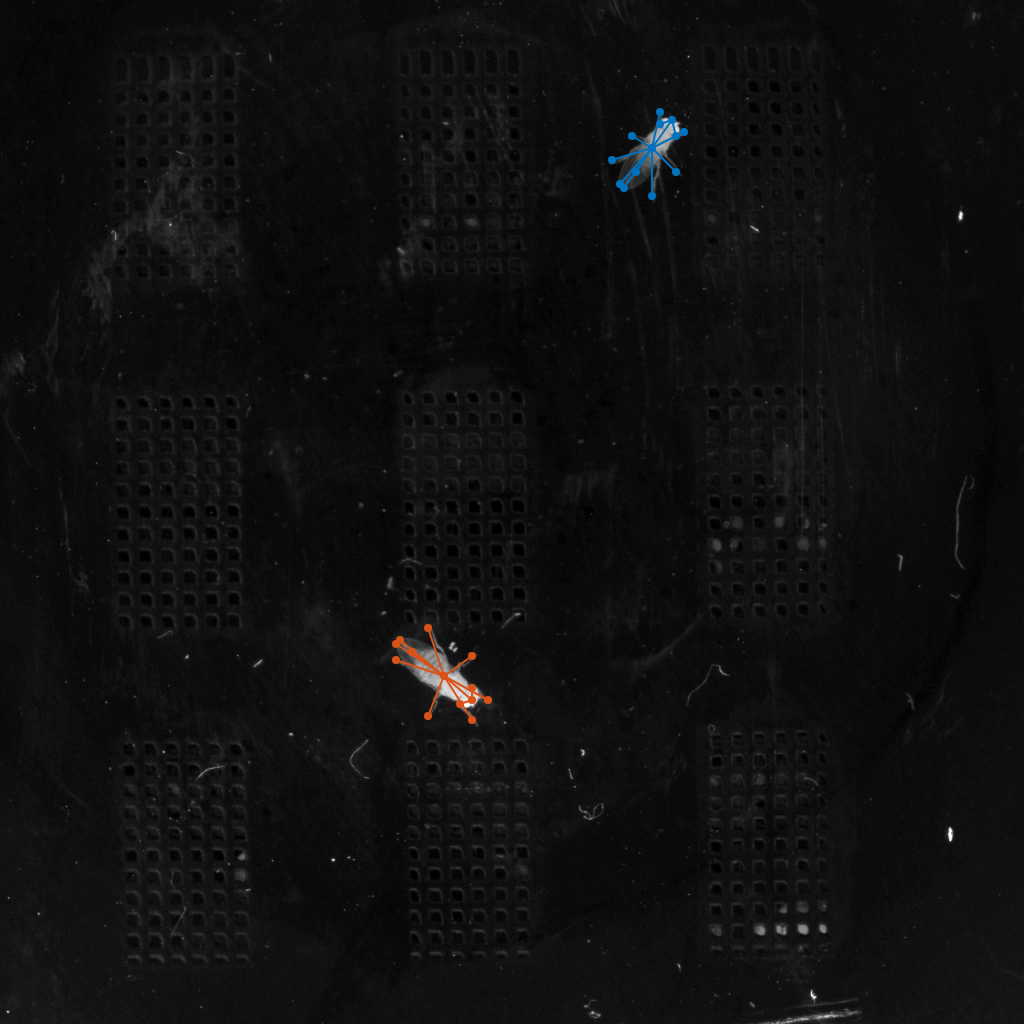

In [38]:
import json
import numpy as np
import sleap_io as sio
from pathlib import Path
from PIL import Image

reference_dir = Path("ios_reference")

reference = json.loads(
    (reference_dir / "reference.json").read_text()
)

skeleton = sio.Skeleton(nodes=reference["nodeNames"])

for source, destination in reference["edges"]:
    skeleton.add_edge(
        reference["nodeNames"][source],
        reference["nodeNames"][destination],
    )

instances = []

for instance in reference["instances"]:
    points = np.array([
        [point["x"], point["y"]] if point is not None
        else [np.nan, np.nan]
        for point in instance["points"]
    ])

    scores = np.array([
        point["score"] if point is not None else np.nan
        for point in instance["points"]
    ])

    instances.append(
        sio.PredictedInstance.from_numpy(
            points,
            skeleton=skeleton,
            point_scores=scores,
        )
    )

sio.render_image(
    instances,
    save_path=reference_dir / "reference_overlay.png",
    image=np.array(
        Image.open(reference_dir / "reference.png").convert("RGB")
    ),
    color_by="instance",
)

display(Image.open(reference_dir / "reference_overlay.png"))

## Fix model export for iOS

ONNX on Swift doesn't handle boolean tensors, so `instance_valid` must be converted to an int

In [39]:
from pathlib import Path
import onnx
from onnx import TensorProto, helper

export_dir = Path("exports/flies_topdown")

model = onnx.load(export_dir / "model.onnx")

# Find the Boolean output.
valid_output = next(
    output
    for output in model.graph.output
    if output.name == "instance_valid"
)

# Add an operation that converts False/True into integer 0/1.
model.graph.node.append(
    helper.make_node(
        "Cast",
        inputs=["instance_valid"],
        outputs=["instance_valid_int32"],
        to=TensorProto.INT32,
    )
)

# Expose the converted output, preserving its existing dimensions.
valid_output.name = "instance_valid_int32"
valid_output.type.tensor_type.elem_type = TensorProto.INT32

# Check the modified graph and save a separate mobile model.
onnx.checker.check_model(model)

output_path = export_dir / "model_ios.onnx"
onnx.save(model, output_path)

print("Saved:", output_path)

Saved: exports/flies_topdown/model_ios.onnx
